<h1 style="color:#0096FF">OLIST"BUSINESS DISCOVERY": Data Analysis & ML</h1>

I started my research from the dataset itself: the **Brazilian E-Commerce Public Dataset by Olist** on Kaggle.

The dataset contains around **100,000 orders from 2016 to 2018**, along with information about customers, sellers, products, payments, reviews, delivery performance, and customer locations. By exploring the dataset description, I started to understand Olist through the data and the type of e-commerce business it was supporting at that time.

This also helped me understand an important point about the analysis: **the dataset represents Olist's historical business, not its current business model.** So, for the purpose of this task, I am looking at Olist from the perspective of **2016–2018**, as if I were analyzing the business during that period.

After understanding the dataset, I visited Olist's official website to learn more about the company and its evolution. I found that Olist has grown beyond the business model represented in the dataset and is now an integrated retail technology ecosystem, offering solutions such as ERP, marketplace integration, e-commerce, logistics, payments, credit, POS, and AI-powered tools.

I also found that **Olist Store was discontinued in June 2026**, with the company shifting its focus toward the Integration Hub, where merchants can connect their own seller accounts to different marketplaces.

This created an important distinction in my research:

**The dataset gives me a historical view of Olist in 2016–2018, while the current website helps me understand how the company has evolved since then.**

Therefore, when analyzing the data and identifying business problems or opportunities, I will keep the analysis focused on the **business context represented by the dataset**, rather than applying Olist's current 2026 model directly to historical data.

This way, the analysis can answer a more realistic question:

**If I were working with Olist during the 2016–2018 period, what could the data tell me about the business, and where could Data and AI create value?**
__________________________________________________________________________________________________________________________________________

## My Approach

After understanding Olist and the dataset, I started working with the data itself. I first used **Python** to explore the dataset and understand the structure of the different files. I checked the columns, data types, missing values, duplicates, and some basic information about each dataset. After that, I cleaned and prepared the data so I could work with it more easily.

Then I moved to **SQL** and created the database with the main tables and their relationships. I used SQL queries to explore the data from a business point of view and answer some basic questions about orders, customers, sellers, delivery, and other parts of the business.

After that, I went back to **Python** to continue the deeper analysis and visualization. I looked at delivery performance, late orders, customer behavior, sellers, customer states, and different patterns over time. I used the results from both SQL and Python to move from simply understanding the data to finding the main business problems and opportunities.

So my overall approach was:

**Dataset Research → Python EDA & Cleaning → SQL Database & Queries → Python Business Analysis & Visualization → Business Insights → Data & AI Solution**


In [429]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Exploratory Data Analysis (EDA) 

### Customers:

In [430]:
customers = pd.read_csv("D:\hiva\olist\dataset\olist_customers_dataset.csv")

In [431]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [432]:
print("Shape:", customers.shape)
print("_"*100)
print("Columns:")
print(customers.columns.tolist())
print("_"*100)
print("Data Types:")
print(customers.dtypes)


Shape: (99441, 5)
____________________________________________________________________________________________________
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
____________________________________________________________________________________________________
Data Types:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object


In [433]:
print("Missing Values:")
print(customers.isnull().sum())
print("_"*100)
print("the num of Duplicates", customers.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(customers.nunique())

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64


### Geolocation:

In [434]:
geolocation = pd.read_csv("D:\hiva\olist\dataset\olist_geolocation_dataset.csv") 

In [435]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [436]:
print("Shape:", geolocation.shape)
print("_"*100)
print("Columns:")
print(geolocation.columns.tolist())
print("_"*100)
print("Data Types:")
print(geolocation.dtypes)
print("_"*100)
print("distribution of latitude & longitude:")
geolocation.describe(include='float')

Shape: (1000163, 5)
____________________________________________________________________________________________________
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
____________________________________________________________________________________________________
Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object
____________________________________________________________________________________________________
distribution of latitude & longitude:


,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06
mean,-2.117615e+01,-4.639054e+01
std,5.715866e+00,4.269748e+00
min,-3.660537e+01,-1.014668e+02
25%,-2.360355e+01,-4.857317e+01
50%,-2.291938e+01,-4.663788e+01
75%,-1.997962e+01,-4.376771e+01
max,4.506593e+01,1.211054e+02


In [437]:
print("Missing Values:")
print(geolocation.isnull().sum())
print("_"*100)
print("the num of Duplicates", geolocation.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(geolocation.nunique())

Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 261831
____________________________________________________________________________________________________
Unique Values:
geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64


### Order Items:

In [438]:
items= pd.read_csv("D:\hiva\olist\dataset\olist_order_items_dataset.csv") 

In [439]:
items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [440]:
print("Shape:", items.shape)
print("_"*100)
print("Columns:")
print(items.columns.tolist())
print("_"*100)
print("Data Types:")
print(items.dtypes)
print("_"*100)
print("distribution of price & freight:")
items.describe(include='float')

Shape: (112650, 7)
____________________________________________________________________________________________________
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
____________________________________________________________________________________________________
Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object
____________________________________________________________________________________________________
distribution of price & freight:


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [441]:
print("Missing Values:")
print(items.isnull().sum())
print("_"*100)
print("the num of Duplicates", items.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(items.nunique())

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64


### Payments:

In [442]:
payments = pd.read_csv("D:\hiva\olist\dataset\olist_order_payments_dataset.csv") 

In [443]:
payments.head

<bound method NDFrame.head of                                 order_id  payment_sequential payment_type  \
0       b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1       a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2       25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3       ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4       42fdf880ba16b47b59251dd489d4441a                   1  credit_card   
...                                  ...                 ...          ...   
103881  0406037ad97740d563a178ecc7a2075c                   1       boleto   
103882  7b905861d7c825891d6347454ea7863f                   1  credit_card   
103883  32609bbb3dd69b3c066a6860554a77bf                   1  credit_card   
103884  b8b61059626efa996a60be9bb9320e10                   1  credit_card   
103885  28bbae6599b09d39ca406b747b6632b1                   1       boleto   

        payment_installments  payment_value  

In [444]:
print("Shape:", payments.shape)
print("_"*100)
print("Columns:")
print(payments.columns.tolist())
print("_"*100)
print("Data Types:")
print(payments.dtypes)
print("_"*100)
print("distribution of payments:")
payments.describe(include='float')

Shape: (103886, 5)
____________________________________________________________________________________________________
Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
____________________________________________________________________________________________________
Data Types:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object
____________________________________________________________________________________________________
distribution of payments:


,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [445]:
print("Missing Values:")
print(payments.isnull().sum())
print("_"*100)
print("the num of Duplicates", payments.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(payments.nunique())

Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64


### Reviews:

In [446]:
reviews = pd.read_csv("D:\hiva\olist\dataset\olist_order_reviews_dataset.csv") 

In [447]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [448]:
print("Shape:", reviews.shape)
print("_"*100)
print("Columns:")
print(reviews.columns.tolist())
print("_"*100)
print("Data Types:")
print(reviews.dtypes)

Shape: (99224, 7)
____________________________________________________________________________________________________
Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
____________________________________________________________________________________________________
Data Types:
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object


In [449]:
print("Missing Values:")
print(reviews.isnull().sum())
print("_"*100)
print("the num of Duplicates", reviews.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(reviews.nunique())

Missing Values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64


### Orders:

In [450]:
orders = pd.read_csv("D:\hiva\olist\dataset\olist_orders_dataset.csv") 

In [451]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [452]:
print("Shape:", orders.shape)
print("_"*100)
print("Columns:")
print(orders.columns.tolist())
print("_"*100)
print("Data Types:")
print(orders.dtypes)


Shape: (99441, 8)
____________________________________________________________________________________________________
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
____________________________________________________________________________________________________
Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [453]:
print("Missing Values:")
print(orders.isnull().sum())
print("_"*100)
print("the num of Duplicates", orders.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(orders.nunique())

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64


### Products:

In [454]:
products = pd.read_csv("D:\hiva\olist\dataset\olist_products_dataset.csv") 

In [455]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [456]:
print("Shape:", products.shape)
print("_"*100)
print("Columns:")
print(products.columns.tolist())
print("_"*100)
print("Data Types:")
print(products.dtypes)


Shape: (32951, 9)
____________________________________________________________________________________________________
Columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
____________________________________________________________________________________________________
Data Types:
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


In [457]:
print("Missing Values:")
print(products.isnull().sum())
print("_"*100)
print("the num of Duplicates", products.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(products.nunique())

Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64


### Sellers:

In [458]:
sellers = pd.read_csv("D:\hiva\olist\dataset\olist_sellers_dataset.csv") 

In [459]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [460]:
print("Shape:", sellers.shape)
print("_"*100)
print("Columns:")
print(sellers.columns.tolist())
print("_"*100)
print("Data Types:")
print(sellers.dtypes)

Shape: (3095, 4)
____________________________________________________________________________________________________
Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
____________________________________________________________________________________________________
Data Types:
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object


In [461]:
print("Missing Values:")
print(sellers.isnull().sum())
print("_"*100)
print("the num of Duplicates", sellers.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(sellers.nunique())

Missing Values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64


### Category Translation:

In [462]:
products_details = pd.read_csv("D:\hiva\olist\dataset\product_category_name_translation.csv") 

In [463]:
products_details.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [464]:
print("Shape:", products_details.shape)
print("_"*100)
print("Data Types:")
print(products_details.dtypes)

Shape: (71, 2)
____________________________________________________________________________________________________
Data Types:
product_category_name            str
product_category_name_english    str
dtype: object


In [465]:
print("Missing Values:")
print(products_details.isnull().sum())
print("_"*100)
print("the num of Duplicates", products_details.duplicated().sum())
print("_"*100)
print("Unique Values:")
print(products_details.nunique())

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64
____________________________________________________________________________________________________
the num of Duplicates 0
____________________________________________________________________________________________________
Unique Values:
product_category_name            71
product_category_name_english    71
dtype: int64


# Stage 1 Summary

- Customers and Sellers: no missing values or duplicates.
- Geolocation: duplicate rows and multiple coordinates per zip code prefix.
- Order Items: date column stored as string and possible price/freight outliers.
- Payments: zero values and multiple records per order.
- Reviews: missing comments and multiple records per order.
- Orders: missing delivery-related dates.
- Products: missing product information and category differences.
- Category Translation: fewer categories than the Products table.

 ## Cleaning & Formatting

The first cleaning steps focus on removing duplicate records and converting date columns into the correct datetime format.

### Geolocation

I removed exact duplicate records while keeping different coordinates for the same zip code prefix.

In [466]:
geolocation_clean = geolocation.drop_duplicates().copy()

print("Original shape:", geolocation.shape)
print("Cleaned shape:", geolocation_clean.shape)
print("Duplicates after cleaning:", geolocation_clean.duplicated().sum())

geolocation_clean.to_csv(
    r"D:\hiva\olist\dataset\geolocation_clean.csv",
    index=False,
    float_format="%.10f"
)

Original shape: (1000163, 5)
Cleaned shape: (738332, 5)
Duplicates after cleaning: 0


### Order Items

I converted `shipping_limit_date` from string to datetime.

In [467]:
items_clean = items.copy()

items_clean["shipping_limit_date"] = pd.to_datetime(
    items_clean["shipping_limit_date"]
)

print(items_clean.dtypes)
print("_"*100)
print("Missing values",items_clean["shipping_limit_date"].isnull().sum())

items_clean.to_csv(
    r"D:\hiva\olist\dataset\items_clean.csv",
    index=False
)


order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object
____________________________________________________________________________________________________
Missing values 0


### Reviews

I converted `review_creation_date` and `review_answer_timestamp` from string to datetime.

In [468]:
reviews_clean = reviews.copy()

reviews_clean["review_creation_date"] = pd.to_datetime(
    reviews_clean["review_creation_date"]
)

reviews_clean["review_answer_timestamp"] = pd.to_datetime(
    reviews_clean["review_answer_timestamp"]
)
print(reviews_clean.dtypes)
print("_" * 100)
print("The Total of Missing Values at Creation Date & Answer Timestamp:")
print(reviews_clean["review_creation_date"].isnull().sum())
print(reviews_clean["review_answer_timestamp"].isnull().sum())

reviews_clean.to_csv(
    r"D:\hiva\olist\dataset\reviews_clean.csv",
    index=False
)

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object
____________________________________________________________________________________________________
The Total of Missing Values at Creation Date & Answer Timestamp:
0
0


### Orders

I converted all order date columns from string to datetime.

In [469]:
orders_clean = orders.copy()

orders_clean["order_purchase_timestamp"] = pd.to_datetime(
    orders_clean["order_purchase_timestamp"]
)

orders_clean["order_approved_at"] = pd.to_datetime(
    orders_clean["order_approved_at"]
)

orders_clean["order_delivered_carrier_date"] = pd.to_datetime(
    orders_clean["order_delivered_carrier_date"]
)

orders_clean["order_delivered_customer_date"] = pd.to_datetime(
    orders_clean["order_delivered_customer_date"]
)

orders_clean["order_estimated_delivery_date"] = pd.to_datetime(
    orders_clean["order_estimated_delivery_date"]
)

print(orders_clean.dtypes)

print("_" * 100)

print("The Total of Missing Values:")

print(orders_clean.isnull().sum())

orders_clean.to_csv(
    r"D:\hiva\olist\dataset\orders_clean.csv",
    index=False
)

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object
____________________________________________________________________________________________________
The Total of Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


### Products

I will check the missing product categories before deciding whether they should be removed or kept.

If all 610 products with missing categories are used in orders, I will keep them without imputing or removing them.

In [470]:
missing_category = products[
    products["product_category_name"].isnull()
]

print(missing_category.shape)
print("_" * 100)
print(missing_category["product_id"].isin(
    items_clean["product_id"]
).sum())

(610, 9)
____________________________________________________________________________________________________
610


### Payments

I will check the zero payment values before deciding whether they should be removed or kept.

If they are associated with valid payment records, I will keep them.

In [471]:
zero_payments = payments[
    payments["payment_value"] == 0
]

zero_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


### Orders: Missing Delivery Dates

I will check the missing delivery dates by `order_status` and inspect delivered orders with missing dates.

If there is not enough evidence to determine the missing values, I will keep them without imputation.

In [472]:
orders_clean[
    [
        "order_status",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].isnull().groupby(
    orders_clean["order_status"]
).sum()

,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,,
approved,0,0,2,2
canceled,0,141,550,619
created,0,5,5,5
delivered,0,14,2,8
invoiced,0,0,314,314
processing,0,0,301,301
shipped,0,0,0,1107
unavailable,0,0,609,609


In [473]:
delivered_missing_dates = orders_clean[
    (orders_clean["order_status"] == "delivered") &
    (
        orders_clean[
            [
                "order_approved_at",
                "order_delivered_carrier_date",
                "order_delivered_customer_date"
            ]
        ].isnull().any(axis=1)
    )
]

delivered_missing_dates

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22


## Stage 2 Summary

In this stage, I removed exact duplicate records from the geolocation data and converted the relevant date columns to datetime format.

I also checked missing product categories, zero payment values, and missing delivery dates. I decided to keep these records because they may represent valid business cases and there was not enough evidence to remove or impute them.

## SQL Analysis

After cleaning and exploring the data in Python, I moved to **SQL** to look at the data from a business point of view. I created a SQL Server database and organized the cleaned files into tables based on their relationships.

Before starting the queries, I created an **ERD** to understand how the main tables are connected. The main relationships are between **customers, orders, order_items, order_payments, order_reviews, products, and sellers**, with **geolocation** and **product_category_translation** as supporting tables.

![ERD](olist_erd.jpeg)

Then I started using SQL queries to get a clearer picture of the business. I looked at the total number of orders and customers, order status, order value, items per order, delivery performance, and customer reviews. I also used SQL to compare late and on-time orders and look at delivery delays across different types of orders.

After getting these basic business insights from SQL, I went back to **Python** to explore the patterns in more detail and create visualizations. I focused more on sellers, customer states, delivery performance, customer behavior, and patterns over time.

This helped me move from simply querying the data to understanding what is happening in the business and where there may be problems worth looking into.


## Business Analysis

### Delivery Time and Customer Satisfaction

In [495]:
review_delivery = reviews_clean.merge(
    orders_clean[
        [
            "order_id",
            "order_status",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ],
    on="order_id"
)

review_delivery = review_delivery[
    review_delivery["order_status"] == "delivered"
].dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

review_delivery["delivery_status"] = "On Time"

review_delivery.loc[
    review_delivery["order_delivered_customer_date"] >
    review_delivery["order_estimated_delivery_date"],
    "delivery_status"
] = "Late"

In [497]:
avg_review = review_delivery.groupby("delivery_status")["review_score"].mean()
avg_review

delivery_status
Late       2.566494
On Time    4.293718
Name: review_score, dtype: float64

C:\Users\skandr store\AppData\Local\Temp\ipykernel_9884\1393523572.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


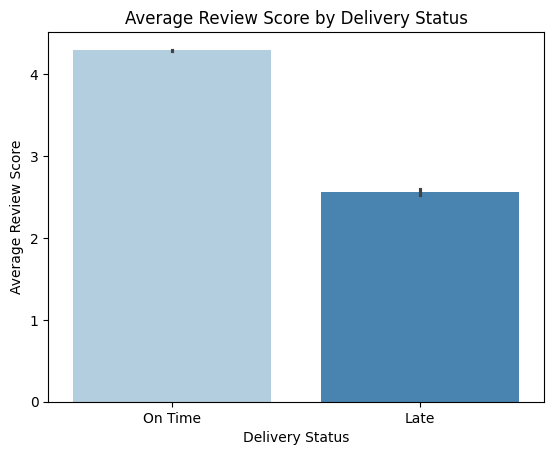

In [476]:
sns.barplot(
    data=review_delivery,
    x="delivery_status",
    y="review_score",
    palette="Blues"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.show()

### Monthly Late Delivery Rate

In [503]:
delivered = orders_clean[
    orders_clean["order_status"] == "delivered"
].dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()

delivered["late"] = (
    delivered["order_delivered_customer_date"] >
    delivered["order_estimated_delivery_date"]
)

monthly_late = (
    delivered.groupby(
        delivered["order_delivered_customer_date"].dt.to_period("M")
    )["late"]
    .agg(["mean", "count"])
)

monthly_late["late_rate"] = monthly_late["mean"] * 100

monthly_late

,mean,count,late_rate
order_delivered_customer_date,,,
2016-10,0.000000,205,0.000000
2016-11,0.034483,58,3.448276
2016-12,0.500000,4,50.000000
2017-01,0.000000,283,0.000000
2017-02,0.001480,1351,0.148038
2017-03,0.026868,2382,2.686818
2017-04,0.055706,1849,5.570579
2017-05,0.060251,3751,6.025060
2017-06,0.035371,3223,3.537077


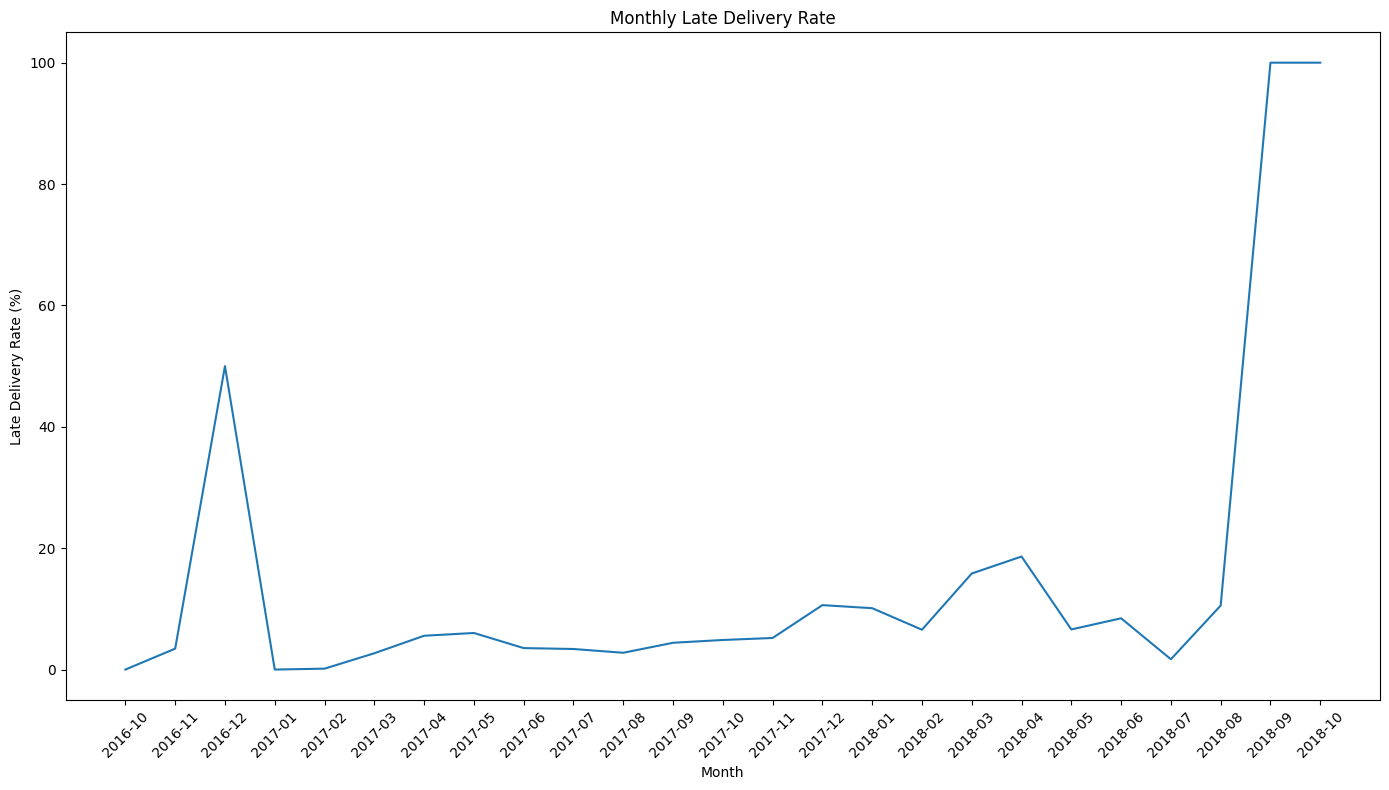

In [505]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    x=monthly_late.index.astype(str),
    y=monthly_late["late_rate"]
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### One-time vs Repeat Customers

In [506]:
customer_orders = orders_clean.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id"
)
customer_orders = customer_orders.groupby(
    "customer_unique_id"
)["order_id"].nunique()

customer_orders.value_counts(normalize=True).sort_index() * 100

order_id
1     96.881244
2      2.856518
3      0.211247
4      0.031219
5      0.008325
6      0.006244
7      0.003122
9      0.001041
17     0.001041
Name: proportion, dtype: float64

In [480]:
customer_type = customer_orders

In [481]:
customer_type = {
    "One Order": (customer_type == 1).sum(),
    "Repeat Customer": (customer_type > 1).sum()
}

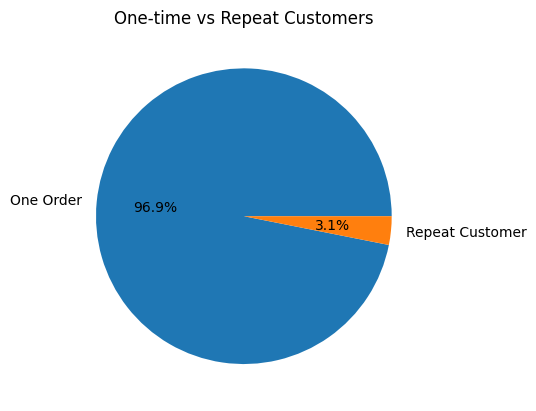

In [482]:
plt.pie(
    customer_type.values(),
    labels=customer_type.keys(),
    autopct="%1.1f%%"
)

plt.title("One-time vs Repeat Customers")
plt.show()

### Delivery Time Distribution

In [483]:
delivered = orders_clean[
    orders_clean["order_status"] == "delivered"
].dropna(subset=["order_purchase_timestamp", "order_delivered_customer_date"])

delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.days

delivered["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

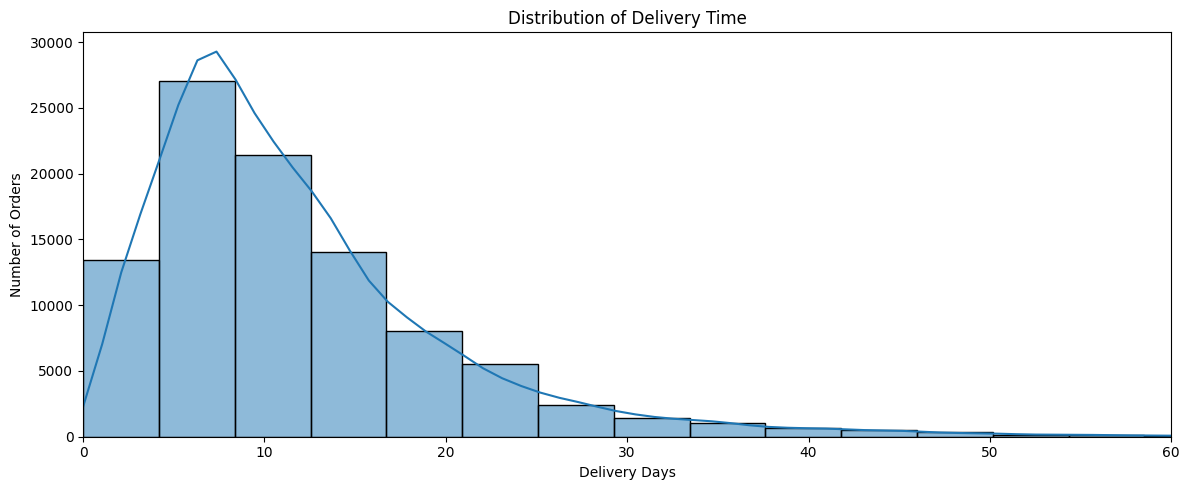

In [484]:
plt.figure(figsize=(12, 5))

sns.histplot(
    delivered["delivery_days"],
    bins=50,
    kde=True
)

plt.xlim(0, 60)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Seller Delivery Performance

In [485]:
seller_analysis = items_clean.merge(
    orders_clean[
        ["order_id",
         "order_status",
         "order_purchase_timestamp",
         "order_delivered_customer_date",
         "order_estimated_delivery_date"]
    ],
    on="order_id"
)

seller_analysis = seller_analysis[
    seller_analysis["order_status"] == "delivered"
].dropna(subset=["order_delivered_customer_date"])

In [486]:
seller_analysis["delivery_days"] = (
    seller_analysis["order_delivered_customer_date"]
    - seller_analysis["order_purchase_timestamp"]
).dt.days

seller_analysis["late"] = (
    seller_analysis["order_delivered_customer_date"]
    > seller_analysis["order_estimated_delivery_date"]
)

In [487]:
seller_summary = seller_analysis.groupby("seller_id").agg(
    orders=("order_id", "nunique"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean"),
    avg_freight=("freight_value", "mean"),
    late_rate=("late", "mean")
).reset_index()

seller_summary["late_rate"] = seller_summary["late_rate"] * 100
seller_summary.head()

,seller_id,orders,avg_delivery_days,avg_price,avg_freight,late_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,10.333333,895.000000,21.020000,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,195,12.628205,104.645427,36.990897,5.555556
2,002100f778ceb8431b7a1020ff7ab48f,50,15.777778,22.529630,14.417778,16.666667
3,003554e2dce176b5555353e4f3555ac8,1,4.000000,120.000000,19.380000,0.000000
4,004c9cd9d87a3c30c522c48c4fc07416,156,13.958333,116.486488,20.977917,7.738095


In [488]:
seller_summary[seller_summary["orders"] >= 50].sort_values(
    "late_rate",
    ascending=False
).head(10)

,seller_id,orders,avg_delivery_days,avg_price,avg_freight,late_rate
1000,54965bbe3e4f07ae045b90b0b8541f52,73,26.234568,127.798765,25.632840,32.098765
1141,6039e27294dc75811c0d8a39069f52c0,63,17.472973,182.443243,31.550270,25.675676
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,96,16.519231,83.143269,16.605000,25.000000
79,06a2c3af7b3aee5d69171b0e14f0ee87,389,17.271144,89.795970,30.028657,23.631841
2211,beadbee30901a7f61d031b6b686095ad,64,13.058824,64.323235,13.787353,23.529412
2365,cac4c8e7b1ca6252d8f20b2fc1a2e4af,74,19.426829,50.343780,18.664756,23.170732
2720,ea566164622c6b439516ab18062c42cd,50,13.807692,198.258077,16.510769,23.076923
2171,bbad7e518d7af88a0897397ffdca1979,68,14.785714,52.694286,15.653810,22.619048
480,2a261b5b644fa05f4f2700eb93544f2c,51,14.036585,65.304878,24.899146,21.951220
1336,712e6ed8aa4aa1fa65dab41fed5737e4,77,23.388235,463.352941,79.586118,21.176471


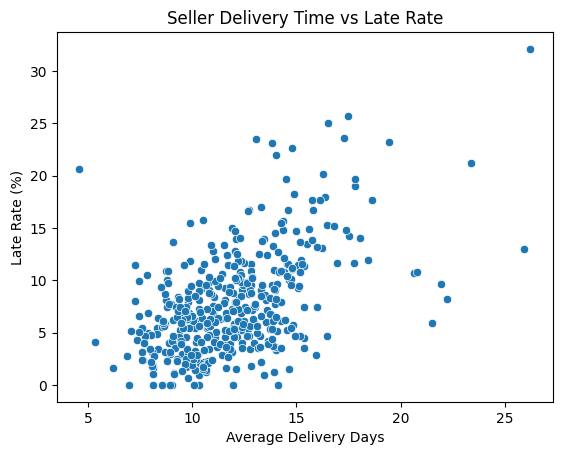

In [489]:
sns.scatterplot(
    data=seller_summary[seller_summary["orders"] >= 50],
    x="avg_delivery_days",
    y="late_rate"
)

plt.title("Seller Delivery Time vs Late Rate")
plt.xlabel("Average Delivery Days")
plt.ylabel("Late Rate (%)")
plt.show()

### Customer State and Delivery Performance

In [490]:
location_analysis = orders_clean.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id"
)

location_orders = location_analysis.groupby(
    "customer_state"
)["order_id"].nunique().sort_values(ascending=False)

location_orders

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64

In [491]:
location_analysis = orders_clean.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id"
)

In [492]:
location_analysis["late"] = (
    location_analysis["order_delivered_customer_date"] >
    location_analysis["order_estimated_delivery_date"]
)
ll = location_analysis[
    location_analysis["order_status"] == "delivered"
].groupby("customer_state")["late"].mean() * 100

ll.sort_values(ascending=False)

customer_state
AL    23.929471
MA    19.665272
PI    15.966387
CE    15.324472
SE    15.223881
BA    14.035627
RJ    13.473684
TO    12.773723
PA    12.367865
ES    12.230576
RR    12.195122
MS    11.554922
PB    11.025145
PE    10.797238
RN    10.759494
SC     9.757473
GO     8.175779
RS     7.146866
DF     7.067308
MT     6.772009
SP     5.893682
MG     5.610358
PR     4.996953
AP     4.477612
AM     4.137931
AC     3.750000
RO     2.880658
Name: late, dtype: float64

In [493]:
state_analysis = location_analysis.groupby("customer_state").agg(
    orders=("order_id", "count"),
    late_rate=("late", "mean")
)

state_analysis["late_rate"] *= 100

state_analysis.sort_values("orders", ascending=False)

,orders,late_rate
customer_state,,
SP,41746,5.717913
RJ,12852,12.947401
MG,11635,5.483455
RS,5466,6.988657
PR,5045,4.876115
SC,3637,9.513335
BA,3380,13.520710
DF,2140,6.869159
ES,2033,12.001968


C:\Users\skandr store\AppData\Local\Temp\ipykernel_9884\4255486332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


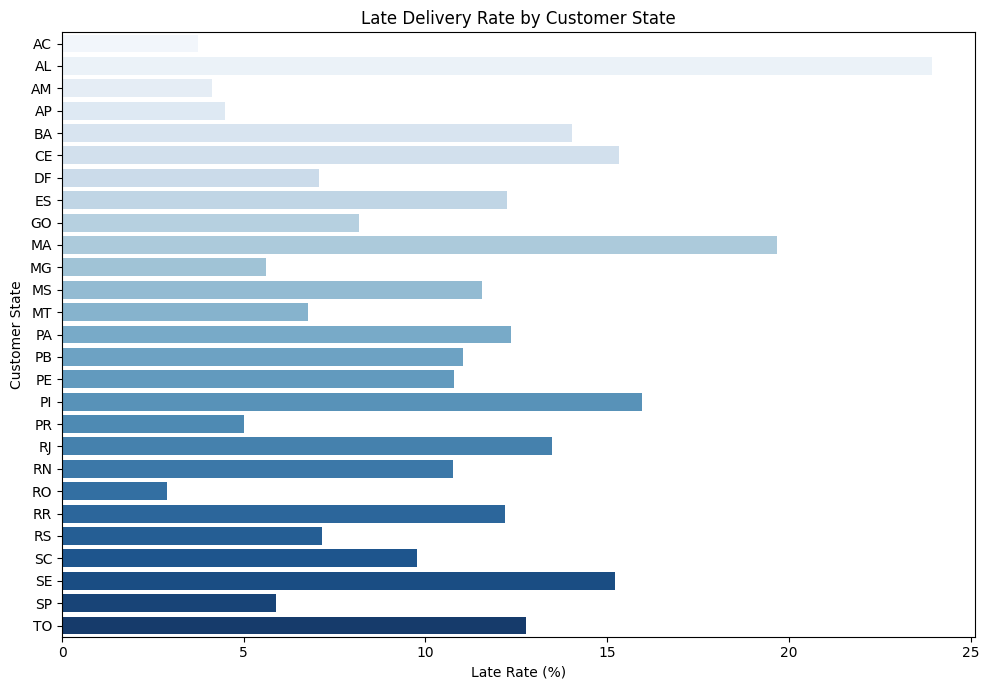

In [494]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=state_late_rate.values,
    y=state_late_rate.index,
    palette="Blues"
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Late Rate (%)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

# The Discovery Mission

### 1. What is happening in the business?

When I looked at the data I found that Olist has a large number of orders but most customers buy only once. Around 96.9% of customers placed only one order while only a small number came back and ordered again.

Then I looked at delivery and found something interesting. On-time orders had an average review score of around 4.3 while late orders had a much lower score of around 2.6. This made me look more closely at delivery performance.

The average delivery time is around 12 days with a median of 10 days. But the main point is not only how long delivery takes. Some orders take much longer than expected and these delays can affect the customer experience.

So from the data I started to see that delivery performance is something Olist needs to keep a close eye on especially when delays happen.
__________________________________________________________________________________________________________________________________________


### 2. Where are the frictions or challenges?

After looking at what is happening in the business I started to look for where the main challenges are.

The clearest challenge is delivery performance. Some orders arrive much later than expected and late orders have much lower review scores than on-time orders. This shows a clear relationship between delivery delays and customer experience.

I also found that the late delivery rate was higher in some periods in 2018 and reached around 18.6% in April. The late rate is also different between states and sellers so delivery performance is not the same everywhere.

Another challenge is customer retention. Around 96.9% of customers placed only one order so only a small number of customers came back for another purchase.
__________________________________________________________________________________________________________________________________________


### 3. What patterns or trends deserve attention?

When I looked deeper into the data, I found that delivery performance is not the same across all sellers and states. Some sellers have longer delivery times and higher late rates than others.

I also noticed that late delivery is not only happening in one place or at one time. The late rate changes across different months and states.

Another pattern is that most customers place only one order. This means that keeping a good customer experience is important because the business has a small number of repeat customers.

These patterns show that delivery performance is an important area to pay attention to, especially across different sellers, states, and time periods.
__________________________________________________________________________________________________________________________________________

### 4. What would management need to understand?

At this point I think management needs to look at delivery from more than one side. The problem is not the same everywhere.

Some sellers have higher late rates and longer delivery times than others. The late rate is also different across customer states and changes over time. At the same time most customers place only one order and late orders have much lower review scores than on-time orders.

Looking at all these points together can help management understand where delivery problems are happening and which sellers, locations, or periods need more attention.


### 5. What evidence supports the conclusions?

The conclusions are supported by SQL queries and Python analysis of the Olist data.

* **Delivery performance:** SQL and Python were used to identify late and on-time orders and analyze delivery delays.
* **Time patterns:** The monthly analysis showed that the late delivery rate changed over time and reached 18.6% in April 2018.
* **Customer satisfaction:** SQL and Python showed that on-time orders had an average review score of around 4.3 compared with around 2.6 for late orders.
* **Delivery time:** Python showed an average delivery time of around 12 days with a median of 10 days.
* **Customers:** Python showed that around 96.9% of customers placed only one order.
* **Sellers and locations:** Python showed differences in delivery performance between sellers and customer states.
* **Order characteristics:** SQL was used to examine delivery delays in relation to the number of items and order value.

Together the SQL queries and Python analysis provide evidence that delivery performance is an important part of the business and that it varies across time sellers locations and different types of orders.
__________________________________________________________________________________________________________________________________________

## How HVIA Can Make a Difference

I think HVIA can help Olist deal with delivery problems in a more proactive way. There are three solutions that can help with this: **Forecasting & Predictive Solutions, Logistics Intelligence, and Analytics & Decision Systems**. They can help Olist understand where delivery problems happen, what needs more attention, and how to make better decisions. The main idea is to not only deal with the problem after it happens, but also try to see it earlier.

If I start with one solution, I will start with **Forecasting & Predictive Solutions** because it is at the heart of the problem. From my analysis, I found that some orders are delivered much later than expected. Olist can deal with these problems when they happen, but I want to move one step earlier and predict which orders may be late before the delay happens. I will use my **Business Analysis** and **GroupBy analysis** to create useful features from sellers, customer states, delivery performance, and order characteristics. Then I will define the target as **late or on-time delivery** and start with a **Random Forest** model. Later I may try other models and compare the results. The goal is to give Olist an early warning so they can take action before the order becomes late.
